Goal: To understand how tokenizers work, explore tokenization algorithms like Byte Pair Encoding (BPE), Sentence Piece.

In [1]:
tokens = list(("The smallest spark within your soul can set the darkest night ablaze. Rise now and claim the morning, for you are the architect of all your days.").encode("utf-8"))

In [2]:
tokens

[84,
 104,
 101,
 32,
 115,
 109,
 97,
 108,
 108,
 101,
 115,
 116,
 32,
 115,
 112,
 97,
 114,
 107,
 32,
 119,
 105,
 116,
 104,
 105,
 110,
 32,
 121,
 111,
 117,
 114,
 32,
 115,
 111,
 117,
 108,
 32,
 99,
 97,
 110,
 32,
 115,
 101,
 116,
 32,
 116,
 104,
 101,
 32,
 100,
 97,
 114,
 107,
 101,
 115,
 116,
 32,
 110,
 105,
 103,
 104,
 116,
 32,
 97,
 98,
 108,
 97,
 122,
 101,
 46,
 32,
 82,
 105,
 115,
 101,
 32,
 110,
 111,
 119,
 32,
 97,
 110,
 100,
 32,
 99,
 108,
 97,
 105,
 109,
 32,
 116,
 104,
 101,
 32,
 109,
 111,
 114,
 110,
 105,
 110,
 103,
 44,
 32,
 102,
 111,
 114,
 32,
 121,
 111,
 117,
 32,
 97,
 114,
 101,
 32,
 116,
 104,
 101,
 32,
 97,
 114,
 99,
 104,
 105,
 116,
 101,
 99,
 116,
 32,
 111,
 102,
 32,
 97,
 108,
 108,
 32,
 121,
 111,
 117,
 114,
 32,
 100,
 97,
 121,
 115,
 46]

In [3]:
my_list = [1, 2, 3, 4, 5]

for i in range(len(my_list) - 1):
    prev, curr = my_list[i], my_list[i + 1]
    print(f"Previous: {prev}, Current: {curr}")

Previous: 1, Current: 2
Previous: 2, Current: 3
Previous: 3, Current: 4
Previous: 4, Current: 5


In [4]:
for prev, curr in zip(my_list[:-1], my_list[1:]):
    print(f"Previous: {prev}, Current: {curr}")

Previous: 1, Current: 2
Previous: 2, Current: 3
Previous: 3, Current: 4
Previous: 4, Current: 5


In [5]:
def get_stats(ids):
    counts = {}
    for prev, curr in zip(ids[:-1], ids[1:]):
        counts[(prev, curr)] = counts.get((prev, curr), 0) + 1
    return counts

stats = get_stats(tokens)
#print(stats)
print(sorted(((v, k) for k, v in stats.items()), reverse=True))

[(6, (101, 32)), (5, (116, 32)), (5, (32, 97)), (4, (116, 104)), (4, (111, 117)), (4, (104, 101)), (4, (97, 114)), (4, (32, 115)), (3, (121, 111)), (3, (114, 32)), (3, (32, 121)), (3, (32, 116)), (2, (117, 114)), (2, (115, 116)), (2, (115, 101)), (2, (114, 107)), (2, (111, 114)), (2, (110, 105)), (2, (110, 32)), (2, (108, 108)), (2, (108, 97)), (2, (108, 32)), (2, (105, 116)), (2, (105, 110)), (2, (104, 105)), (2, (101, 115)), (2, (100, 97)), (2, (97, 110)), (2, (97, 108)), (2, (32, 110)), (2, (32, 100)), (2, (32, 99)), (1, (122, 101)), (1, (121, 115)), (1, (119, 105)), (1, (119, 32)), (1, (117, 108)), (1, (117, 32)), (1, (116, 101)), (1, (115, 112)), (1, (115, 111)), (1, (115, 109)), (1, (115, 46)), (1, (114, 110)), (1, (114, 101)), (1, (114, 99)), (1, (112, 97)), (1, (111, 119)), (1, (111, 102)), (1, (110, 111)), (1, (110, 103)), (1, (110, 100)), (1, (109, 111)), (1, (109, 97)), (1, (109, 32)), (1, (108, 101)), (1, (107, 101)), (1, (107, 32)), (1, (105, 115)), (1, (105, 109)), (1, (1

In [6]:
top_pair = max(stats, key=stats.get)
top_pair

(101, 32)

merge([5, 6, 6, 7, 9, 1], (6, 7), 99)

when we call this function
(6, 7) should be merged to 99 and the resulting list would be [5, 6 ,99, 9, 1]

In [7]:
def merge(ids, pair, idx):
    # maintain a new list of ids that were merged
    newids = []
    i = 0
    while i < len(ids):
        if i < len(ids) - 1 and ((ids[i], ids[i+1]) == pair):
            newids.append(idx)
            i += 2
        else:
            newids.append(ids[i])
            i += 1
    return newids


tok = merge([5, 6, 6, 7, 9, 1], (6, 7), 99)
print(tok)

[5, 6, 99, 9, 1]


In [8]:
# making the text longer to have more representative token statistics
# text from elricwan/HarryPotter (hugging face data set) - chapter 1 from 1-Harry-Potter-and-the-Sorcerer’s-Stone.txt

text = """THE BOY WHO LIVED


Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you’d expect to be involved in anything strange or mysterious, because they just didn’t hold with such nonsense.

Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large mustache. Mrs. Dursley was thin and blonde and had nearly twice the usual amount of neck, which came in very useful as she spent so much of her time craning over garden fences, spying on the neighbors. The Dursleys had a small son called Dudley and in their opinion there was no finer boy anywhere.

The Dursleys had everything they wanted, but they also had a secret, and their greatest fear was that somebody would discover it. They didn’t think they could bear it if anyone found out about the Potters. Mrs. Potter was Mrs. Dursley’s sister, but they hadn’t met for several years; in fact, Mrs. Dursley pretended she didn’t have a sister, because her sister and her good-for-nothing husband were as unDursleyish as it was possible to be. The Dursleys shuddered to think what the neighbors would say if the Potters arrived in the street. The Dursleys knew that the Potters had a small son, too, but they had never even seen him. This boy was another good reason for keeping the Potters away; they didn’t want Dudley mixing with a child like that.

When Mr. and Mrs. Dursley woke up on the dull, gray Tuesday our story starts, there was nothing about the cloudy sky outside to suggest that strange and mysterious things would soon be happening all over the country. Mr. Dursley hummed as he picked out his most boring tie for work, and Mrs. Dursley gossiped away happily as she wrestled a screaming Dudley into his high chair.

None of them noticed a large, tawny owl flutter past the window.

At half past eight, Mr. Dursley picked up his briefcase, pecked Mrs. Dursley on the cheek, and tried to kiss Dudley good-bye but missed, because Dudley was now having a tantrum and throwing his cereal at the walls. “Little tyke,” chortled Mr. Dursley as he left the house. He got into his car and backed out of number four’s drive.

It was on the corner of the street that he noticed the first sign of something peculiar — a cat reading a map. For a second, Mr. Dursley didn’t realize what he had seen — then he jerked his head around to look again. There was a tabby cat standing on the corner of Privet Drive, but there wasn’t a map in sight. What could he have been thinking of? It must have been a trick of the light. Mr. Dursley blinked and stared at the cat. It stared back. As Mr. Dursley drove around the corner and up the road, he watched the cat in his mirror. It was now reading the sign that said Privet Drive — no, looking at the sign; cats couldn’t read maps or signs. Mr. Dursley gave himself a little shake and put the cat out of his mind. As he drove toward town he thought of nothing except a large order of drills he was hoping to get that day.

But on the edge of town, drills were driven out of his mind by something else. As he sat in the usual morning traffic jam, he couldn’t help noticing that there seemed to be a lot of strangely dressed people about. People in cloaks. Mr. Dursley couldn’t bear people who dressed in funny clothes — the getups you saw on young people! He supposed this was some stupid new fashion. He drummed his fingers on the steering wheel and his eyes fell on a huddle of these weirdos standing quite close by. They were whispering excitedly together. Mr. Dursley was enraged to see that a couple of them weren’t young at all; why, that man had to be older than he was, and wearing an emerald-green cloak! The nerve of him! But then it struck Mr. Dursley that this was probably some silly stunt — these people were obviously collecting for something . . . yes, that would be it. The traffic moved on and a few minutes later, Mr. Dursley arrived in the Grunnings parking lot, his mind back on drills.

Mr. Dursley always sat with his back to the window in his office on the ninth floor. If he hadn’t, he might have found it harder to concentrate on drills that morning. He didn’t see the owls swooping past in broad daylight, though people down in the street did; they pointed and gazed open-mouthed as owl after owl sped overhead. Most of them had never seen an owl even at nighttime. Mr. Dursley, however, had a perfectly normal, owl-free morning. He yelled at five different people. He made several important telephone calls and shouted a bit more. He was in a very good mood until lunchtime, when he thought he’d stretch his legs and walk across the road to buy himself a bun from the bakery.

He’d forgotten all about the people in cloaks until he passed a group of them next to the baker’s. He eyed them angrily as he passed. He didn’t know why, but they made him uneasy. This bunch were whispering excitedly, too, and he couldn’t see a single collecting tin. It was on his way back past them, clutching a large doughnut in a bag, that he caught a few words of what they were saying.

“The Potters, that’s right, that’s what I heard —”

“— yes, their son, Harry —”

Mr. Dursley stopped dead. Fear flooded him. He looked back at the whisperers as if he wanted to say something to them, but thought better of it.

He dashed back across the road, hurried up to his office, snapped at his secretary not to disturb him, seized his telephone, and had almost finished dialing his home number when he changed his mind. He put the receiver back down and stroked his mustache, thinking . . . no, he was being stupid. Potter wasn’t such an unusual name. He was sure there were lots of people called Potter who had a son called Harry. Come to think of it, he wasn’t even sure his nephew was called Harry. He’d never even seen the boy. It might have been Harvey. Or Harold. There was no point in worrying Mrs. Dursley; she always got so upset at any mention of her sister. He didn’t blame her — if he’d had a sister like that . . . but all the same, those people in cloaks . . .

He found it a lot harder to concentrate on drills that afternoon and when he left the building at five o’clock, he was still so worried that he walked straight into someone just outside the door.

“Sorry,” he grunted, as the tiny old man stumbled and almost fell. It was a few seconds before Mr. Dursley realized that the man was wearing a violet cloak. He didn’t seem at all upset at being almost knocked to the ground. On the contrary, his face split into a wide smile and he said in a squeaky voice that made passersby stare, “Don’t be sorry, my dear sir, for nothing could upset me today! Rejoice, for You-Know-Who has gone at last! Even Muggles like yourself should be celebrating, this happy, happy day!”

And the old man hugged Mr. Dursley around the middle and walked off.

Mr. Dursley stood rooted to the spot. He had been hugged by a complete stranger. He also thought he had been called a Muggle, whatever that was. He was rattled. He hurried to his car and set off for home, hoping he was imagining things, which he had never hoped before, because he didn’t approve of imagination.

As he pulled into the driveway of number four, the first thing he saw — and it didn’t improve his mood — was the tabby cat he’d spotted that morning. It was now sitting on his garden wall. He was sure it was the same one; it had the same markings around its eyes.

“Shoo!” said Mr. Dursley loudly.

The cat didn’t move. It just gave him a stern look. Was this normal cat behavior? Mr. Dursley wondered. Trying to pull himself together, he let himself into the house. He was still determined not to mention anything to his wife.

Mrs. Dursley had had a nice, normal day. She told him over dinner all about Mrs. Next Door’s problems with her daughter and how Dudley had learned a new word (“Won’t!”). Mr. Dursley tried to act normally. When Dudley had been put to bed, he went into the living room in time to catch the last report on the evening news:

“And finally, bird-watchers everywhere have reported that the nation’s owls have been behaving very unusually today. Although owls normally hunt at night and are hardly ever seen in daylight, there have been hundreds of sightings of these birds flying in every direction since sunrise. Experts are unable to explain why the owls have suddenly changed their sleeping pattern.” The newscaster allowed himself a grin. “Most mysterious. And now, over to Jim McGuffin with the weather. Going to be any more showers of owls tonight, Jim?”

“Well, Ted,” said the weatherman, “I don’t know about that, but it’s not only the owls that have been acting oddly today. Viewers as far apart as Kent, Yorkshire, and Dundee have been phoning in to tell me that instead of the rain I promised yesterday, they’ve had a downpour of shooting stars! Perhaps people have been celebrating Bonfire Night early — it’s not until next week, folks! But I can promise a wet night tonight.”

Mr. Dursley sat frozen in his armchair. Shooting stars all over Britain? Owls flying by daylight? Mysterious people in cloaks all over the place? And a whisper, a whisper about the Potters . . .

Mrs. Dursley came into the living room carrying two cups of tea. It was no good. He’d have to say something to her. He cleared his throat nervously. “Er — Petunia, dear — you haven’t heard from your sister lately, have you?”

As he had expected, Mrs. Dursley looked shocked and angry. After all, they normally pretended she didn’t have a sister.

“No,” she said sharply. “Why?”

“Funny stuff on the news,” Mr. Dursley mumbled. “Owls . . . shooting stars . . . and there were a lot of funny-looking people in town today . . .”

“So?” snapped Mrs. Dursley.

“Well, I just thought . . . maybe . . . it was something to do with . . . you know . . . her crowd.”

Mrs. Dursley sipped her tea through pursed lips. Mr. Dursley wondered whether he dared tell her he’d heard the name “Potter.” He decided he didn’t dare. Instead he said, as casually as he could, “Their son — he’d be about Dudley’s age now, wouldn’t he?”

“I suppose so,” said Mrs. Dursley stiffly.

“What’s his name again? Howard, isn’t it?”

“Harry. Nasty, common name, if you ask me.”

“Oh, yes,” said Mr. Dursley, his heart sinking horribly. “Yes, I quite agree.”

He didn’t say another word on the subject as they went upstairs to bed. While Mrs. Dursley was in the bathroom, Mr. Dursley crept to the bedroom window and peered down into the front garden. The cat was still there. It was staring down Privet Drive as though it were waiting for something.

Was he imagining things? Could all this have anything to do with the Potters? If it did . . . if it got out that they were related to a pair of — well, he didn’t think he could bear it.

The Dursleys got into bed. Mrs. Dursley fell asleep quickly but Mr. Dursley lay awake, turning it all over in his mind. His last, comforting thought before he fell asleep was that even if the Potters were involved, there was no reason for them to come near him and Mrs. Dursley. The Potters knew very well what he and Petunia thought about them and their kind. . . . He couldn’t see how he and Petunia could get mixed up in anything that might be going on — he yawned and turned over — it couldn’t affect them. . . .

How very wrong he was.

Mr. Dursley might have been drifting into an uneasy sleep, but the cat on the wall outside was showing no sign of sleepiness. It was sitting as still as a statue, its eyes fixed unblinkingly on the far corner of Privet Drive. It didn’t so much as quiver when a car door slammed on the next street, nor when two owls swooped overhead. In fact, it was nearly midnight before the cat moved at all.

A man appeared on the corner the cat had been watching, appeared so suddenly and silently you’d have thought he’d just popped out of the ground. The cat’s tail twitched and its eyes narrowed.

Nothing like this man had ever been seen on Privet Drive. He was tall, thin, and very old, judging by the silver of his hair and beard, which were both long enough to tuck into his belt. He was wearing long robes, a purple cloak that swept the ground, and high-heeled, buckled boots. His blue eyes were light, bright, and sparkling behind half-moon spectacles and his nose was very long and crooked, as though it had been broken at least twice. This man’s name was Albus Dumbledore.

Albus Dumbledore didn’t seem to realize that he had just arrived in a street where everything from his name to his boots was unwelcome. He was busy rummaging in his cloak, looking for something. But he did seem to realize he was being watched, because he looked up suddenly at the cat, which was still staring at him from the other end of the street. For some reason, the sight of the cat seemed to amuse him. He chuckled and muttered, “I should have known.”

He found what he was looking for in his inside pocket. It seemed to be a silver cigarette lighter. He flicked it open, held it up in the air, and clicked it. The nearest street lamp went out with a little pop. He clicked it again — the next lamp flickered into darkness. Twelve times he clicked the Put-Outer, until the only lights left on the whole street were two tiny pinpricks in the distance, which were the eyes of the cat watching him. If anyone looked out of their window now, even beady-eyed Mrs. Dursley, they wouldn’t be able to see anything that was happening down on the pavement. Dumbledore slipped the Put-Outer back inside his cloak and set off down the street toward number four, where he sat down on the wall next to the cat. He didn’t look at it, but after a moment he spoke to it.

“Fancy seeing you here, Professor McGonagall.”

He turned to smile at the tabby, but it had gone. Instead he was smiling at a rather severe-looking woman who was wearing square glasses exactly the shape of the markings the cat had had around its eyes. She, too, was wearing a cloak, an emerald one. Her black hair was drawn into a tight bun. She looked distinctly ruffled.

“How did you know it was me?” she asked.

“My dear Professor, I’ve never seen a cat sit so stiffly.”

“You’d be stiff if you’d been sitting on a brick wall all day,” said Professor McGonagall.

“All day? When you could have been celebrating? I must have passed a dozen feasts and parties on my way here.”

Professor McGonagall sniffed angrily.

“Oh yes, everyone’s celebrating, all right,” she said impatiently. “You’d think they’d be a bit more careful, but no — even the Muggles have noticed something’s going on. It was on their news.” She jerked her head back at the Dursleys’ dark living-room window. “I heard it. Flocks of owls . . . shooting stars. . . . Well, they’re not completely stupid. They were bound to notice something. Shooting stars down in Kent — I’ll bet that was Dedalus Diggle. He never had much sense.”

“You can’t blame them,” said Dumbledore gently. “We’ve had precious little to celebrate for eleven years.”

“I know that,” said Professor McGonagall irritably. “But that’s no reason to lose our heads. People are being downright careless, out on the streets in broad daylight, not even dressed in Muggle clothes, swapping rumors.”

She threw a sharp, sideways glance at Dumbledore here, as though hoping he was going to tell her something, but he didn’t, so she went on. “A fine thing it would be if, on the very day You-Know-Who seems to have disappeared at last, the Muggles found out about us all. I suppose he really has gone, Dumbledore?”

“It certainly seems so,” said Dumbledore. “We have much to be thankful for. Would you care for a lemon drop?”

“A what?”

“A lemon drop. They’re a kind of Muggle sweet I’m rather fond of.”

“No, thank you,” said Professor McGonagall coldly, as though she didn’t think this was the moment for lemon drops. “As I say, even if You-Know-Who has gone —”

“My dear Professor, surely a sensible person like yourself can call him by his name? All this ‘You-Know-Who’ nonsense — for eleven years I have been trying to persuade people to call him by his proper name: Voldemort.” Professor McGonagall flinched, but Dumbledore, who was unsticking two lemon drops, seemed not to notice. “It all gets so confusing if we keep saying ‘You-Know-Who.’ I have never seen any reason to be frightened of saying Voldemort’s name.”

“I know you haven’t,” said Professor McGonagall, sounding half exasperated, half admiring. “But you’re different. Everyone knows you’re the only one You-Know- oh, all right, Voldemort, was frightened of.”

“You flatter me,” said Dumbledore calmly. “Voldemort had powers I will never have.”

“Only because you’re too — well — noble to use them.”

“It’s lucky it’s dark. I haven’t blushed so much since Madam Pomfrey told me she liked my new earmuffs.”

Professor McGonagall shot a sharp look at Dumbledore and said, “The owls are nothing next to the rumors that are flying around. You know what everyone’s saying? About why he’s disappeared? About what finally stopped him?”

It seemed that Professor McGonagall had reached the point she was most anxious to discuss, the real reason she had been waiting on a cold, hard wall all day, for neither as a cat nor as a woman had she fixed Dumbledore with such a piercing stare as she did now. It was plain that whatever “everyone” was saying, she was not going to believe it until Dumbledore told her it was true. Dumbledore, however, was choosing another lemon drop and did not answer.

“What they’re saying,” she pressed on, “is that last night Voldemort turned up in Godric’s Hollow. He went to find the Potters. The rumor is that Lily and James Potter are — are — that they’re — dead.”

Dumbledore bowed his head. Professor McGonagall gasped.

“Lily and James . . . I can’t believe it . . . I didn’t want to believe it . . . Oh, Albus . . .”

Dumbledore reached out and patted her on the shoulder. “I know . . . I know . . .” he said heavily.

Professor McGonagall’s voice trembled as she went on. “That’s not all. They’re saying he tried to kill the Potters’ son, Harry. But — he couldn’t. He couldn’t kill that little boy. No one knows why, or how, but they’re saying that when he couldn’t kill Harry Potter, Voldemort’s power somehow broke — and that’s why he’s gone.”

Dumbledore nodded glumly.

“It’s — it’s true?” faltered Professor McGonagall. “After all he’s done . . . all the people he’s killed . . . he couldn’t kill a little boy? It’s just astounding . . . of all the things to stop him . . . but how in the name of heaven did Harry survive?”

“We can only guess,” said Dumbledore. “We may never know.”

Professor McGonagall pulled out a lace handkerchief and dabbed at her eyes beneath her spectacles. Dumbledore gave a great sniff as he took a golden watch from his pocket and examined it. It was a very odd watch. It had twelve hands but no numbers; instead, little planets were moving around the edge. It must have made sense to Dumbledore, though, because he put it back in his pocket and said, “Hagrid’s late. I suppose it was he who told you I’d be here, by the way?”

“Yes,” said Professor McGonagall. “And I don’t suppose you’re going to tell me why you’re here, of all places?”

“I’ve come to bring Harry to his aunt and uncle. They’re the only family he has left now.”

“You don’t mean — you can’t mean the people who live here?” cried Professor McGonagall, jumping to her feet and pointing at number four. “Dumbledore — you can’t. I’ve been watching them all day. You couldn’t find two people who are less like us. And they’ve got this son — I saw him kicking his mother all the way up the street, screaming for sweets. Harry Potter come and live here!”

“It’s the best place for him,” said Dumbledore firmly. “His aunt and uncle will be able to explain everything to him when he’s older. I’ve written them a letter.”

“A letter?” repeated Professor McGonagall faintly, sitting back down on the wall. “Really, Dumbledore, you think you can explain all this in a letter? These people will never understand him! He’ll be famous — a legend — I wouldn’t be surprised if today was known as Harry Potter Day in the future — there will be books written about Harry — every child in our world will know his name!”

“Exactly,” said Dumbledore, looking very seriously over the top of his half-moon glasses. “It would be enough to turn any boy’s head. Famous before he can walk and talk! Famous for something he won’t even remember! Can’t you see how much better off he’ll be, growing up away from all that until he’s ready to take it?”

Professor McGonagall opened her mouth, changed her mind, swallowed, and then said, “Yes — yes, you’re right, of course. But how is the boy getting here, Dumbledore?” She eyed his cloak suddenly as though she thought he might be hiding Harry underneath it.

“Hagrid’s bringing him.”

“You think it — wise — to trust Hagrid with something as important as this?”

“I would trust Hagrid with my life,” said Dumbledore.

“I’m not saying his heart isn’t in the right place,” said Professor McGonagall grudgingly, “but you can’t pretend he’s not careless. He does tend to — what was that?”

A low rumbling sound had broken the silence around them. It grew steadily louder as they looked up and down the street for some sign of a headlight; it swelled to a roar as they both looked up at the sky — and a huge motorcycle fell out of the air and landed on the road in front of them.

If the motorcycle was huge, it was nothing to the man sitting astride it. He was almost twice as tall as a normal man and at least five times as wide. He looked simply too big to be allowed, and so wild — long tangles of bushy black hair and beard hid most of his face, he had hands the size of trash can lids, and his feet in their leather boots were like baby dolphins. In his vast, muscular arms he was holding a bundle of blankets.

“Hagrid,” said Dumbledore, sounding relieved. “At last. And where did you get that motorcycle?”

“Borrowed it, Professor Dumbledore, sir,” said the giant, climbing carefully off the motorcycle as he spoke. “Young Sirius Black lent it to me. I’ve got him, sir.”

“No problems, were there?”

“No, sir — house was almost destroyed, but I got him out all right before the Muggles started swarmin’ around. He fell asleep as we was flyin’ over Bristol.”

Dumbledore and Professor McGonagall bent forward over the bundle of blankets. Inside, just visible, was a baby boy, fast asleep. Under a tuft of jet-black hair over his forehead they could see a curiously shaped cut, like a bolt of lightning.

“Is that where — ?” whispered Professor McGonagall.

“Yes,” said Dumbledore. “He’ll have that scar forever.”

“Couldn’t you do something about it, Dumbledore?”

“Even if I could, I wouldn’t. Scars can come in handy. I have one myself above my left knee that is a perfect map of the London Underground. Well — give him here, Hagrid — we’d better get this over with.”

Dumbledore took Harry in his arms and turned toward the Dursleys’ house.

“Could I — could I say good-bye to him, sir?” asked Hagrid. He bent his great, shaggy head over Harry and gave him what must have been a very scratchy, whiskery kiss. Then, suddenly, Hagrid let out a howl like a wounded dog.

“Shhh!” hissed Professor McGonagall, “you’ll wake the Muggles!”

“S-s-sorry,” sobbed Hagrid, taking out a large, spotted handkerchief and burying his face in it. “But I c-c-can’t stand it — Lily an’ James dead — an’ poor little Harry off ter live with Muggles —”

“Yes, yes, it’s all very sad, but get a grip on yourself, Hagrid, or we’ll be found,” Professor McGonagall whispered, patting Hagrid gingerly on the arm as Dumbledore stepped over the low garden wall and walked to the front door. He laid Harry gently on the doorstep, took a letter out of his cloak, tucked it inside Harry’s blankets, and then came back to the other two. For a full minute the three of them stood and looked at the little bundle; Hagrid’s shoulders shook, Professor McGonagall blinked furiously, and the twinkling light that usually shone from Dumbledore’s eyes seemed to have gone out.

“Well,” said Dumbledore finally, “that’s that. We’ve no business staying here. We may as well go and join the celebrations.”

“Yeah,” said Hagrid in a very muffled voice, “I’d best get this bike away. G’night, Professor McGonagall — Professor Dumbledore, sir.”

Wiping his streaming eyes on his jacket sleeve, Hagrid swung himself onto the motorcycle and kicked the engine into life; with a roar it rose into the air and off into the night.

“I shall see you soon, I expect, Professor McGonagall,” said Dumbledore, nodding to her. Professor McGonagall blew her nose in reply.

Dumbledore turned and walked back down the street. On the corner he stopped and took out the silver Put-Outer. He clicked it once, and twelve balls of light sped back to their street lamps so that Privet Drive glowed suddenly orange and he could make out a tabby cat slinking around the corner at the other end of the street. He could just see the bundle of blankets on the step of number four.

“Good luck, Harry,” he murmured. He turned on his heel and with a swish of his cloak, he was gone.

A breeze ruffled the neat hedges of Privet Drive, which lay silent and tidy under the inky sky, the very last place you would expect astonishing things to happen. Harry Potter rolled over inside his blankets without waking up. One small hand closed on the letter beside him and he slept on, not knowing he was special, not knowing he was famous, not knowing he would be woken in a few hours’ time by Mrs. Dursley’s scream as she opened the front door to put out the milk bottles, nor that he would spend the next few weeks being prodded and pinched by his cousin Dudley. . . . He couldn’t know that at this very moment, people meeting in secret all over the country were holding up their glasses and saying in hushed voices: “To Harry Potter — the boy who lived!”
"""


tokens = text.encode("utf-8") # raw-bytes
tokens = list(map(int, tokens)) # 0 ... 255

In [9]:
len(tokens)

26844

In [10]:
vocab_size = 276 # desired final vocabulary size
num_merges = vocab_size - 256
ids = list(tokens) # creates copy

merges = {}
for i in range(num_merges):
    stats = get_stats(ids)
    pair = max(stats, key=stats.get)
    idx = 256 + i
    ids = merge(ids, pair, idx)
    merges[pair] = idx

In [11]:
merges

{(101, 32): 256,
 (116, 32): 257,
 (100, 32): 258,
 (116, 104): 259,
 (226, 128): 260,
 (115, 32): 261,
 (105, 110): 262,
 (46, 32): 263,
 (101, 114): 264,
 (44, 32): 265,
 (121, 32): 266,
 (111, 117): 267,
 (108, 101): 268,
 (262, 103): 269,
 (97, 110): 270,
 (259, 256): 271,
 (111, 114): 272,
 (111, 110): 273,
 (260, 153): 274,
 (269, 32): 275}

In [12]:
print("tokens length:", len(tokens))
print("ids length:", len(ids))
print(f"compression ratio: {len(tokens) / len(ids):.2f}X")

tokens length: 26844
ids length: 20574
compression ratio: 1.30X


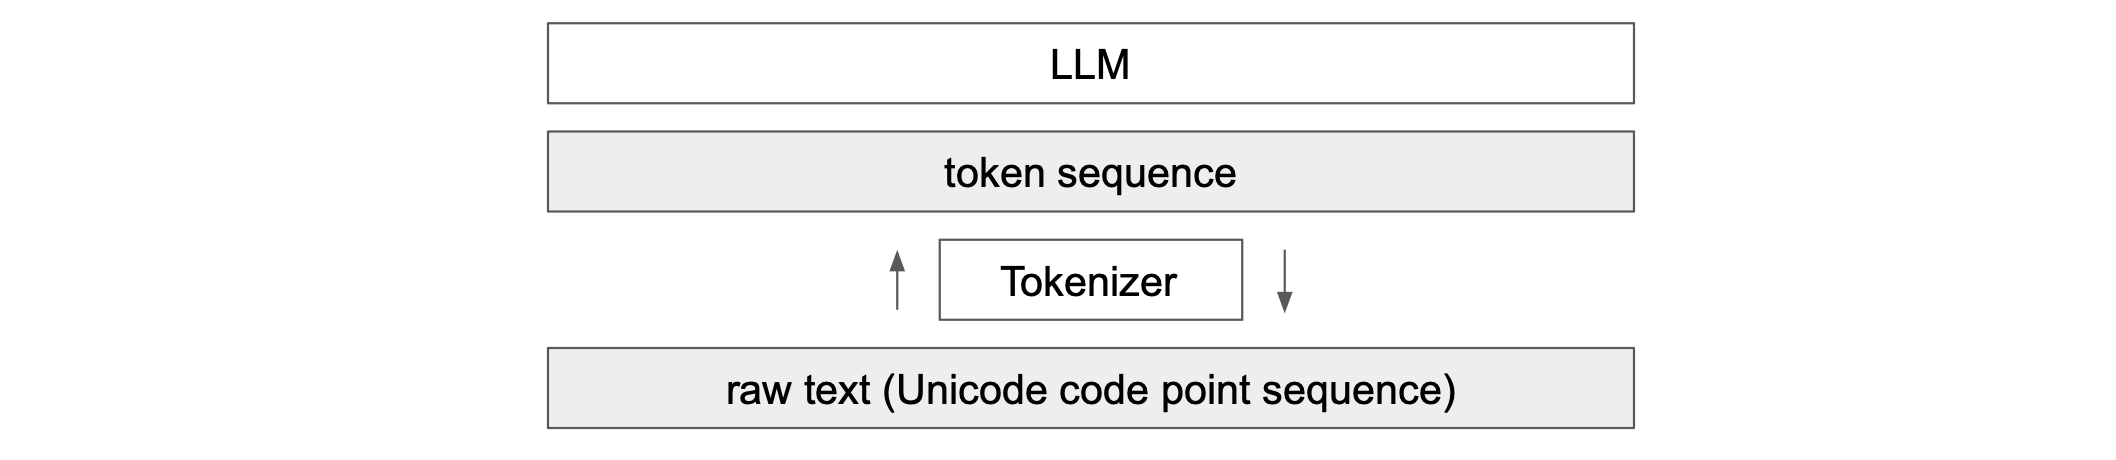

In [13]:
merges.items()

dict_items([((101, 32), 256), ((116, 32), 257), ((100, 32), 258), ((116, 104), 259), ((226, 128), 260), ((115, 32), 261), ((105, 110), 262), ((46, 32), 263), ((101, 114), 264), ((44, 32), 265), ((121, 32), 266), ((111, 117), 267), ((108, 101), 268), ((262, 103), 269), ((97, 110), 270), ((259, 256), 271), ((111, 114), 272), ((111, 110), 273), ((260, 153), 274), ((269, 32), 275)])

In [17]:
# decoding - given a sequence of integers in the range (0, vocab_size), what is the text ?

vocab = {idx: bytes([idx]) for idx in range(256)}
# print(vocab)
for (p0, p1), idx in merges.items():
    vocab[idx] = vocab[p0] + vocab[p1]

def decode(ids):
    tokens = b"".join(vocab[idx] for idx in ids)
    text = tokens.decode("utf-8", errors="replace")
    return text

In [18]:
decode([123])

'{'

In [21]:
get_stats(tokens)

{(84, 72): 1,
 (72, 69): 1,
 (69, 32): 1,
 (32, 66): 10,
 (66, 79): 1,
 (79, 89): 1,
 (89, 32): 1,
 (32, 87): 11,
 (87, 72): 1,
 (72, 79): 1,
 (79, 32): 1,
 (32, 76): 4,
 (76, 73): 1,
 (73, 86): 1,
 (86, 69): 1,
 (69, 68): 1,
 (68, 10): 1,
 (10, 10): 111,
 (10, 77): 10,
 (77, 114): 51,
 (114, 46): 56,
 (46, 32): 331,
 (32, 97): 423,
 (97, 110): 195,
 (110, 100): 182,
 (100, 32): 492,
 (32, 77): 80,
 (114, 115): 122,
 (115, 46): 56,
 (32, 68): 106,
 (68, 117): 102,
 (117, 114): 96,
 (115, 108): 72,
 (108, 101): 254,
 (101, 121): 111,
 (121, 44): 33,
 (44, 32): 259,
 (32, 111): 230,
 (111, 102): 114,
 (102, 32): 111,
 (32, 110): 128,
 (110, 117): 13,
 (117, 109): 57,
 (109, 98): 51,
 (98, 101): 109,
 (101, 114): 305,
 (114, 32): 230,
 (32, 102): 117,
 (102, 111): 47,
 (111, 117): 232,
 (114, 44): 17,
 (32, 80): 63,
 (80, 114): 38,
 (114, 105): 100,
 (105, 118): 36,
 (118, 101): 189,
 (101, 116): 98,
 (116, 32): 508,
 (68, 114): 8,
 (101, 44): 51,
 (32, 119): 294,
 (119, 101): 71,
 (114, 

In [26]:
# encoding - given a string, return a list of integers (tokens)
def encode(text):
    tokens = list(text.encode('utf-8'))
    while len(tokens) >= 2:
        stats = get_stats(tokens)
        pair = min(stats, key=lambda p: merges.get(p, float("inf")))
        if pair not in merges:
            # nothing else can be merged
            break
        idx = merges[pair]
        tokens = merge(tokens, pair, idx)
    return tokens

sample = encode("hello world!")

In [23]:
sample

[104, 101, 108, 108, 111, 32, 119, 272, 108, 100, 33]

In [27]:
encode("h")

[104]

In [28]:
# validation
valtext = """Physics of AI, as the name suggests, means studying AI in the same way we study physics.
It aims to answer the following questions (so simple that they may sound trivial):

What models, on what data, exhibit what phenomena?
(Bonus: why?)

There are three core elements here: models, data, and phenomena.
To emphasize data and phenomena (which are often overlooked by the community), I deliberately fold many details—such as optimizers and loss functions—into the notion of the model.

"""

val_out = decode(encode(valtext))
print(val_out == valtext)

True


In [29]:
import regex as re
gpt2pat = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")

In [30]:
example_pat = """Hi! I'am the best Machine Learning Engineer"""
print(re.findall(gpt2pat, example_pat))

['Hi', '!', ' I', "'", 'am', ' the', ' best', ' Machine', ' Learning', ' Engineer']
